In [21]:
# % pip install medmnist
# to download the dataset for the medmnist package

In [1]:
import torch 
import numpy as np
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn 
import torchvision.models as models
from medmnist.dataset import PathMNIST
from medmnist import INFO
from torch.utils.data import DataLoader

from torchvision import transforms

d:\Develop\Andaconda\envs\pytorch_gpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# In order to match the normalization with the perTrained Model, we need to transform the dataset with the same image normalization
pretrain_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    ) # The normalization for the ImageNet
])

raw_transform = transforms.Compose([
    # transforms.Resize((224,224)),
    transforms.ToTensor(),
])

train_dataset = PathMNIST(split='train', transform=raw_transform, download=True)
val_dataset = PathMNIST(split='val', transform=raw_transform, download=True)
test_dataset = PathMNIST(split='test', transform=raw_transform, download=True)

data_flag = 'pathmnist'
info = INFO[data_flag]

Using downloaded and verified file: C:\Users\Windows\.medmnist\pathmnist.npz
Using downloaded and verified file: C:\Users\Windows\.medmnist\pathmnist.npz
Using downloaded and verified file: C:\Users\Windows\.medmnist\pathmnist.npz


### EDA

In [12]:
print("Dataset name:", data_flag)
print("Task:", info['task'])
print("Number of channels:", info['n_channels'])
print("Number of classes:", len(info['label']))
print("Labels:", info['label'])

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Dataset name: pathmnist
Task: multi-class
Number of channels: 3
Number of classes: 9
Labels: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}
Train size: 89996
Validation size: 10004
Test size: 7180


In [13]:
img, label = train_dataset[0]

print("Image shape:", img.shape)   # [C, H, W]
print("Label:", label)
print("Image min:", img.min().item())
print("Image max:", img.max().item())

Image shape: torch.Size([3, 28, 28])
Label: [0]
Image min: 0.6431372761726379
Image max: 0.8941176533699036


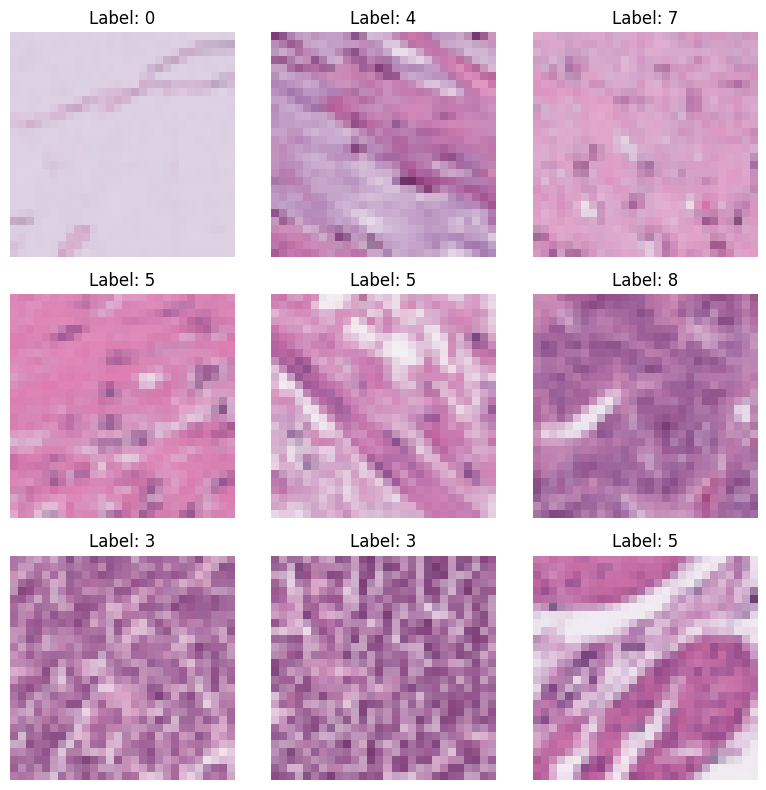

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    
    # PathMNIST usually has 3 channels, so transpose to HWC
    img_np = img.permute(1, 2, 0).numpy()
    
    ax.imshow(img_np)
    ax.set_title(f"Label: {label.item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Preprocessing

In [ ]:
# # Normalized the pixel range from 0~1 to -1~1
# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize(
#         mean=(0.5,0.5,0.5),
#         std=(0.5,0.5,0.5)
#     )
# ])

# Architecture Building 

In [6]:
class pretrainVGG16_PathMNIST(nn.Module):
    def __init__(self, num_classes=9):
        # Override 
        super(pretrainVGG16_PathMNIST, self).__init__()
        
        # Load the pretrained VGG16
        self.vgg16 = models.vgg16(pretrained=True)

        # Freeze the layers of VGG16
        for para in self.vgg16.parameters():
            para.requires_grad = False

        # Replace the last fully connected layer with a new one
        # Make it fits the number of PM classes 
        in_features = self.vgg16.classifier[6].in_features
        self.vgg16.classifier[6] = nn.Linear(
            in_features=in_features,
            out_features=num_classes
        ) 

    def forward(self, x):
        output = self.vgg16(x)
        return output



In [4]:
train_dataset = PathMNIST(split='train', transform=pretrain_transform, download=True)
val_dataset = PathMNIST(split='val', transform=pretrain_transform, download=True)
test_dataset = PathMNIST(split='test', transform=pretrain_transform, download=True)
train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True) 

Using downloaded and verified file: C:\Users\Windows\.medmnist\pathmnist.npz
Using downloaded and verified file: C:\Users\Windows\.medmnist\pathmnist.npz
Using downloaded and verified file: C:\Users\Windows\.medmnist\pathmnist.npz


In [7]:
# model Check
model = pretrainVGG16_PathMNIST()
x, y = train_dataset[0]
x = x.unsqueeze(0)
out = model(x)
print(out)

d:\Develop\Andaconda\envs\pytorch_gpu\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\Develop\Andaconda\envs\pytorch_gpu\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


tensor([[-0.0349, -0.8761, -0.0016,  0.2349, -0.1800,  0.1358, -0.2762,  0.0064,
          0.3088]], grad_fn=<AddmmBackward0>)


In [16]:
class VGG16_PathMNIST(nn.Module):
    def __init__(self, num_classes=9):
        # Override 
        super(VGG16_PathMNIST, self).__init__()

        # VGG16 convolution blocks
        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        # classifier
        self.classifier = nn.Sequential(
            nn.Linear(512*7*7, 4096),
            nn.ReLU(True),
            nn.Dropout(),

            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(),

            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, start_dim=1)
        output = self.classifier(x)
        return output



# Training and Hyper-parameter tuning 

In [8]:
from train import TrainConfig, TrainHistoryRecords, train
model = pretrainVGG16_PathMNIST()
config = TrainConfig(
    epochs=3,
    lr=1e-3,
    optimizer_cls=torch.optim.Adam,
    device="cuda",
    save_checkpoints=False
)
history = train(model = model,
                train_loader = train_dataloader,
                config = config)

+++++++++++++++++++++++++++++++++++++++++
Training starts on: cuda
+++++++++++++++++++++++++++++++++++++++++

Training on Epoch: 2
Current Total Loss: 291.7449951171875, Accuracy: 0.171875, 
Current Total Loss: 2392.7033081054688, Accuracy: 0.4119318181818182, 
Current Total Loss: 3756.4214401245117, Accuracy: 0.5234375, 
Current Total Loss: 4950.120948791504, Accuracy: 0.5751008064516129, 
Current Total Loss: 6046.43839263916, Accuracy: 0.6086128048780488, 
Current Total Loss: 7115.22395324707, Accuracy: 0.6288296568627451, 
Current Total Loss: 8108.740081787109, Accuracy: 0.6469006147540983, 
Current Total Loss: 9107.441993713379, Accuracy: 0.6581205985915493, 
Current Total Loss: 10072.871421813965, Accuracy: 0.6665702160493827, 
Current Total Loss: 11000.594161987305, Accuracy: 0.6737637362637363, 
Current Total Loss: 11880.484313964844, Accuracy: 0.6830136138613861, 
Current Total Loss: 12701.296577453613, Accuracy: 0.6914414414414415, 
Current Total Loss: 13574.17259979248, Accur

KeyboardInterrupt: 

# Evaluation with Validation

# Performace Metrics